In [1]:
import  pandas as pd   #dataframes for working with tabular data
import numpy  as np  # numerical operations

#visulization
import matplotlib.pyplot as plt 
import seaborn as sns

#scikit learn  machine learning 
# Machine preprocessing 
from sklearn.model_selection import train_test_split   # split data into train/test sets
from sklearn.preprocessing import StandardScaler  # standardize numerical features / columns
from sklearn.preprocessing import LabelEncoder  # Encode categorical columns


#machine learning Model 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 


# Machine Learning Evaluation

from sklearn.metrics import (accuracy_score, 
                               precision_score, 
                               recall_score, 
                               f1_score, 
                               confusion_matrix,
                               classification_report, 
                               roc_auc_score,
                               roc_curve)

#Setting
import warnings
warnings.filterwarnings('ignore')

sns.set_style ('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

#Set random seed for reproducility

RANDOM_STATE = 42

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
#uploading the csv file

DATA_CAPSTONE= "applicant_datasett_1000.csv"

DATA_CAPSTONE= "applicant_datasett_1000.csv"

df = pd.read_csv(DATA_CAPSTONE)
print(f"data loaded successfully!")
print(f"shape: {df.shape[0]:} row x {df.shape[1]} columns")

df = pd.read_csv(DATA_CAPSTONE)
print(f"data loaded successfully!")
print(f"shape: {df.shape[0]:} row x {df.shape[1]} columns")

data loaded successfully!
shape: 1000 row x 14 columns
data loaded successfully!
shape: 1000 row x 14 columns


In [3]:
df.head()

,id,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed,label
0,1,1,HS,0.37,3,2,5,5,1,47,0,0,0,Will Get Interview
1,2,1,HS,0.01,2,1,9,9,4,178,0,0,0,Will Get Interview
2,3,1,HS,0.21,4,1,1,4,1,124,1,1,0,Will Get Interview
3,4,16,PhD,0.97,6,2,5,1,8,115,0,0,2,Best Suited for Role
4,5,22,HS,0.98,5,1,7,10,8,165,1,0,4,Best Suited for Role


In [4]:
df. describe()

,id,years_experience,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,7.405000,0.333700,4.594000,2.745000,4.428000,4.842000,4.302000,110.432000,0.303000,0.454000,1.030000
std,288.819436,7.768483,0.272697,4.421845,2.492828,2.779666,2.920542,2.774616,51.514067,0.459785,0.498129,1.276217
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,20.000000,0.000000,0.000000,0.000000
25%,250.750000,2.000000,0.110000,1.000000,1.000000,2.000000,2.000000,2.000000,66.000000,0.000000,0.000000,0.000000
50%,500.500000,5.000000,0.260000,3.000000,2.000000,4.000000,4.000000,4.000000,110.000000,0.000000,0.000000,0.000000
75%,750.250000,11.000000,0.510000,7.000000,5.000000,7.000000,7.000000,6.000000,155.000000,1.000000,1.000000,2.000000
max,1000.000000,30.000000,1.000000,15.000000,8.000000,10.000000,10.000000,10.000000,200.000000,1.000000,1.000000,4.000000


In [5]:
df. isnull()

,id,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed,label
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
df = df.drop(columns=["id"])

In [7]:
df.head()

,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed,label
0,1,HS,0.37,3,2,5,5,1,47,0,0,0,Will Get Interview
1,1,HS,0.01,2,1,9,9,4,178,0,0,0,Will Get Interview
2,1,HS,0.21,4,1,1,4,1,124,1,1,0,Will Get Interview
3,16,PhD,0.97,6,2,5,1,8,115,0,0,2,Best Suited for Role
4,22,HS,0.98,5,1,7,10,8,165,1,0,4,Best Suited for Role


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   years_experience       1000 non-null   int64  
 1   education_level        1000 non-null   object 
 2   skills_match_score     1000 non-null   float64
 3   num_relevant_projects  1000 non-null   int64  
 4   certifications         1000 non-null   int64  
 5   communication_score    1000 non-null   int64  
 6   leadership_score       1000 non-null   int64  
 7   culture_fit_score      1000 non-null   int64  
 8   previous_salary_k      1000 non-null   int64  
 9   location_match         1000 non-null   int64  
 10  applied_before         1000 non-null   int64  
 11  num_interviews_passed  1000 non-null   int64  
 12  label                  1000 non-null   object 
dtypes: float64(1), int64(10), object(2)
memory usage: 101.7+ KB


In [9]:
df.isnull().sum()

years_experience         0
education_level          0
skills_match_score       0
num_relevant_projects    0
certifications           0
communication_score      0
leadership_score         0
culture_fit_score        0
previous_salary_k        0
location_match           0
applied_before           0
num_interviews_passed    0
label                    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.head(20)

,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed,label
0,1,HS,0.37,3,2,5,5,1,47,0,0,0,Will Get Interview
1,1,HS,0.01,2,1,9,9,4,178,0,0,0,Will Get Interview
2,1,HS,0.21,4,1,1,4,1,124,1,1,0,Will Get Interview
3,16,PhD,0.97,6,2,5,1,8,115,0,0,2,Best Suited for Role
4,22,HS,0.98,5,1,7,10,8,165,1,0,4,Best Suited for Role
5,1,Bachelor,0.09,6,3,4,1,2,47,0,1,0,Best Match for Role
6,7,HS,0.93,5,1,3,1,3,153,0,0,0,Best Match for Role
7,1,Master,0.92,15,2,8,8,10,21,0,0,2,Best Suited for Role
8,0,HS,0.20,8,3,2,4,1,52,0,0,0,Will Get Interview
9,3,HS,0.97,0,0,2,1,4,68,0,0,0,Will Get Interview


In [12]:
numerical_columns = df.select_dtypes(include="number")
print(len(numerical_columns.columns))

11


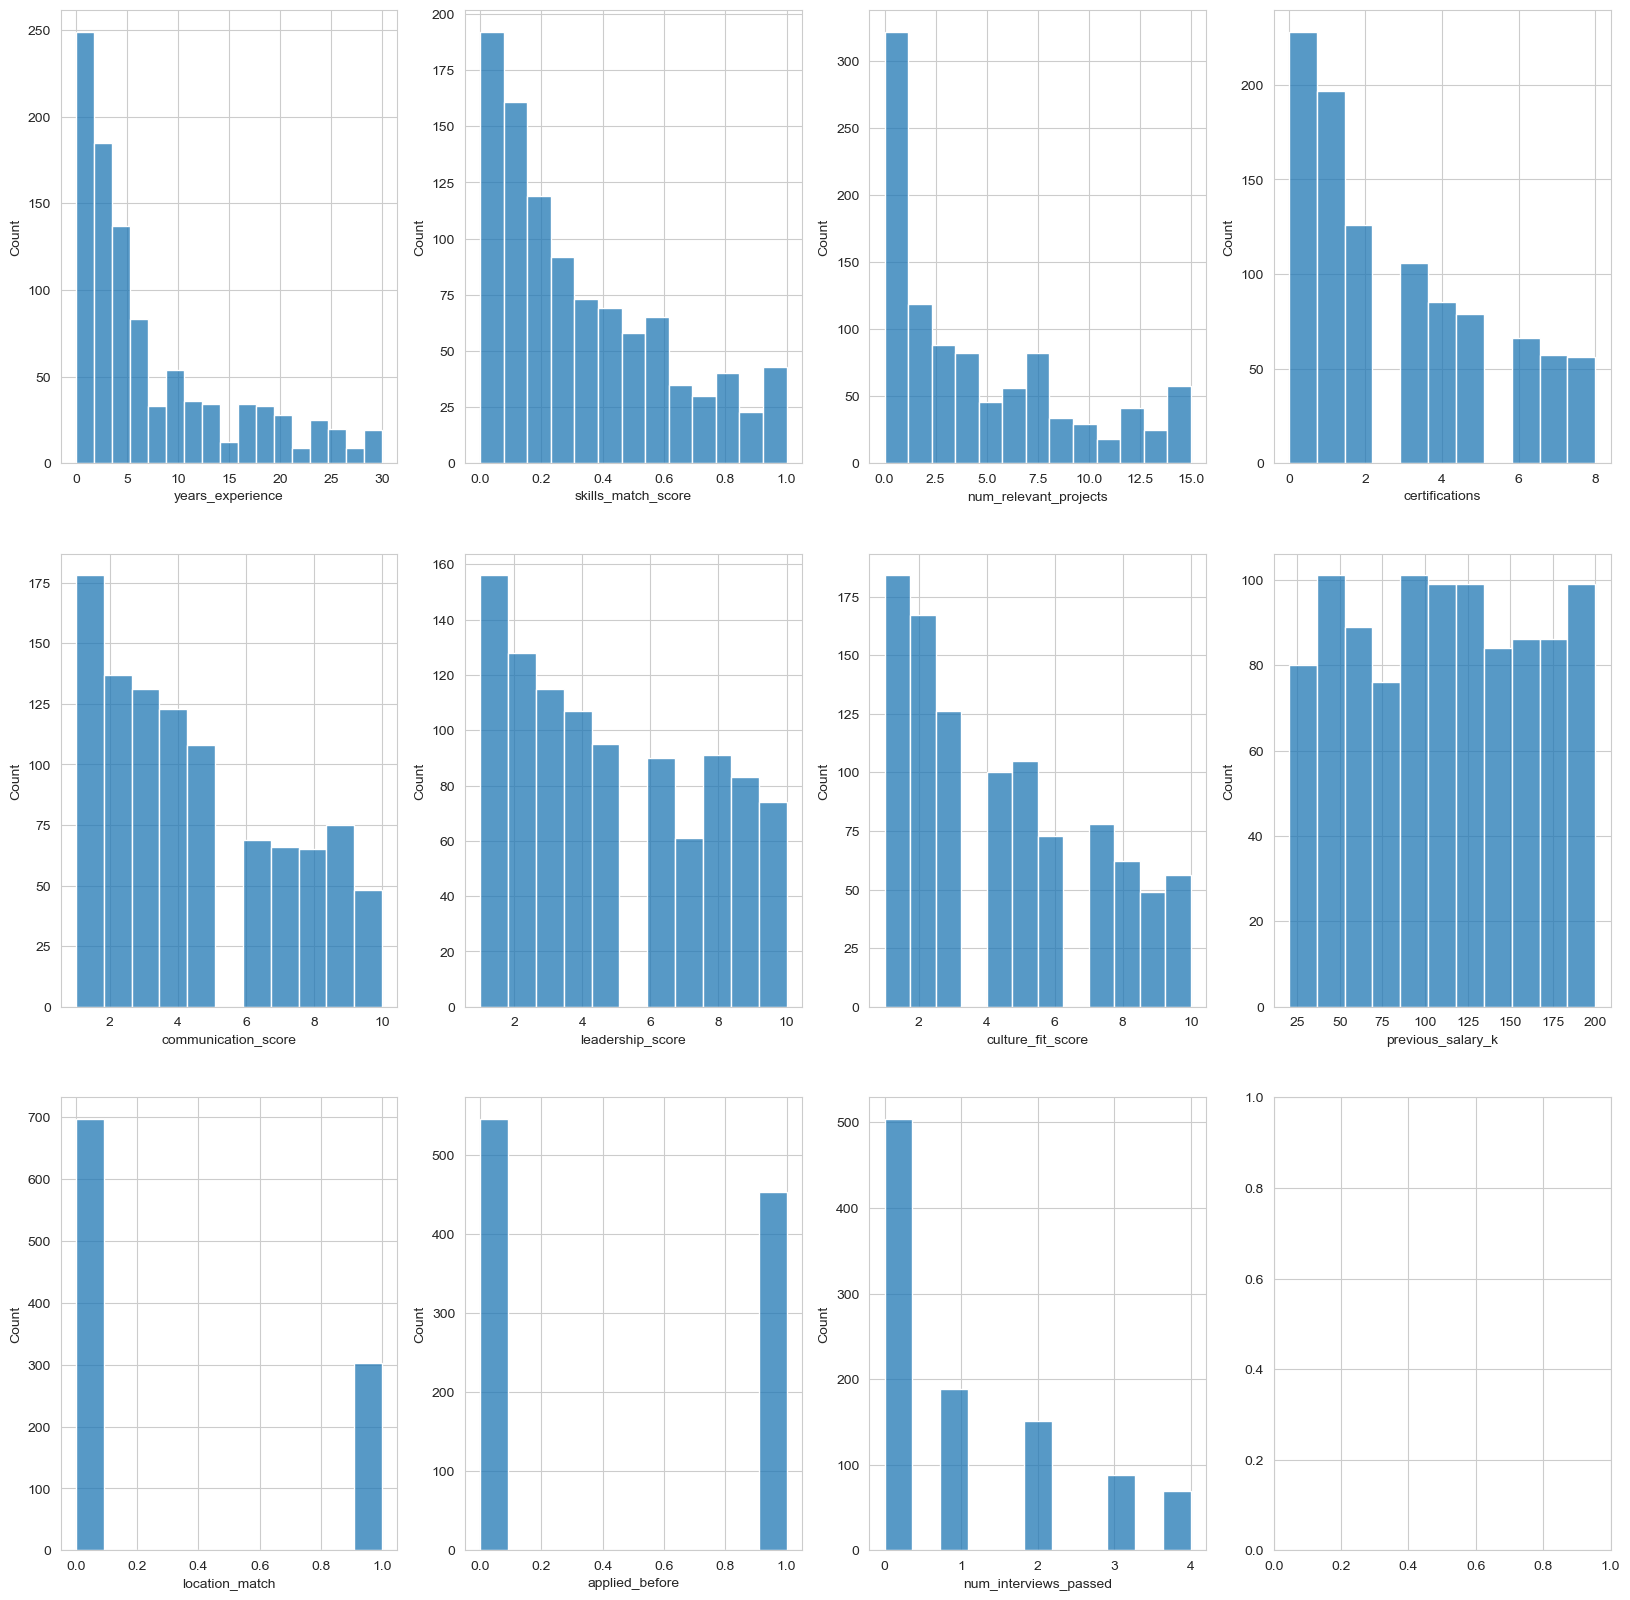

In [13]:
fig, ax = plt.subplots(nrows=3,ncols=4, figsize=(20,20))
ax = ax.flatten()
for nk, col in enumerate(numerical_columns):
    sns.histplot(df[col], ax=ax[nk])
plt.show()
    

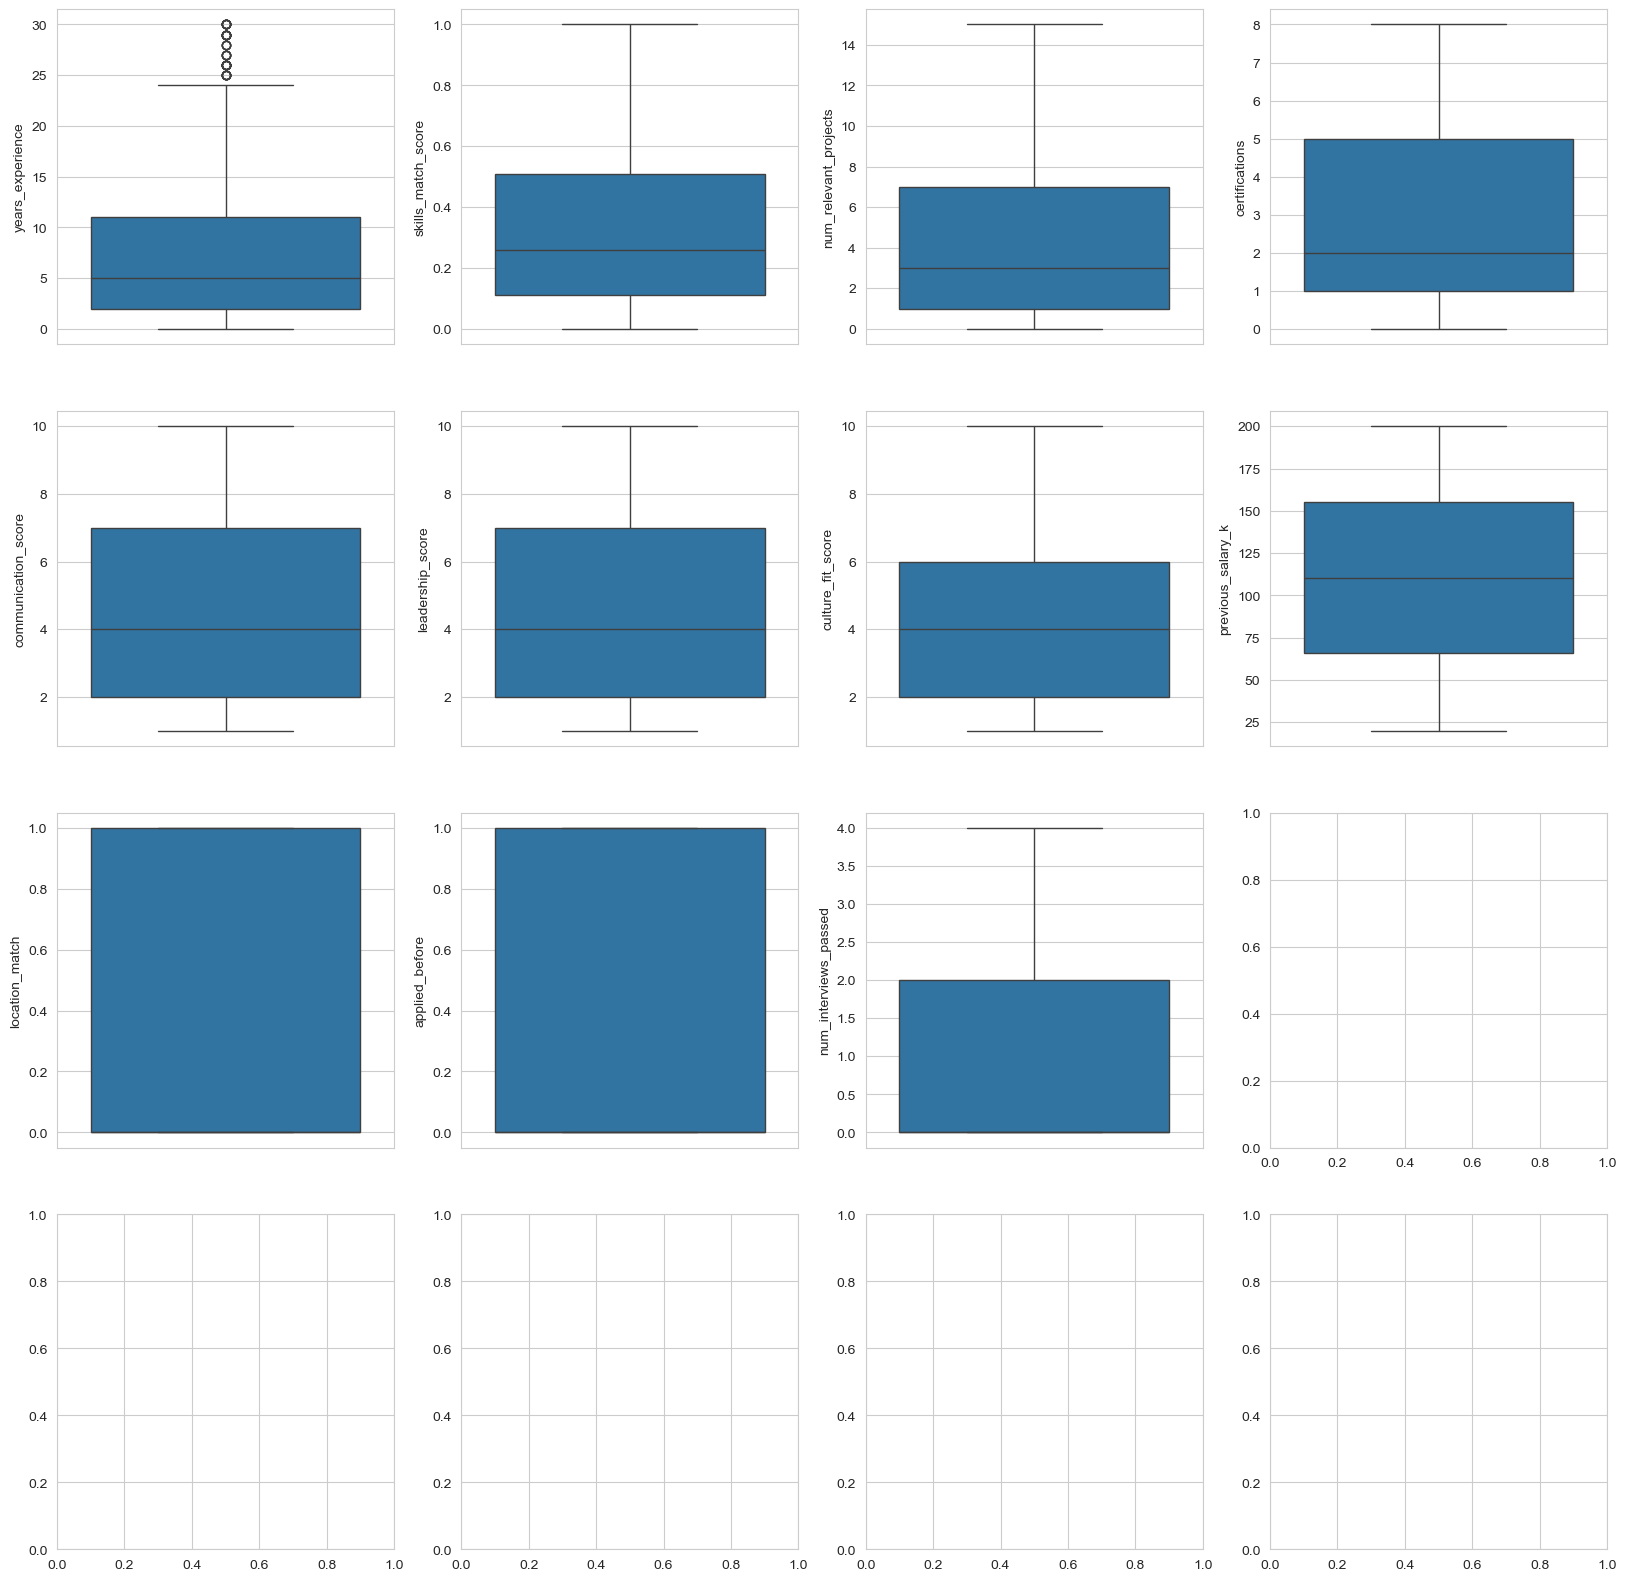

In [14]:
fig, ax = plt.subplots(nrows=4,ncols=4, figsize=(20,20))
ax = ax.flatten()
for nk, col in enumerate(numerical_columns):
    sns.boxplot(df[col], ax=ax[nk]) 
plt.show()
    

## exploratory data analysis

In [15]:
affected_column = ["years_experience"]

In [16]:
q1 = df[affected_column].quantile(0.25)
q3 = df[affected_column].quantile(0.75)

In [17]:
 iqr = q3-q1

In [18]:
lower_bound = q1 -  (1.5*iqr)
upper_bound = q3 + (1.5*iqr)

In [19]:
lower_bound

years_experience   -11.5
dtype: float64

In [20]:
upper_bound

years_experience    24.5
dtype: float64

In [21]:
df[affected_column] = df[affected_column].clip(lower = lower_bound, upper = upper_bound, axis=1)

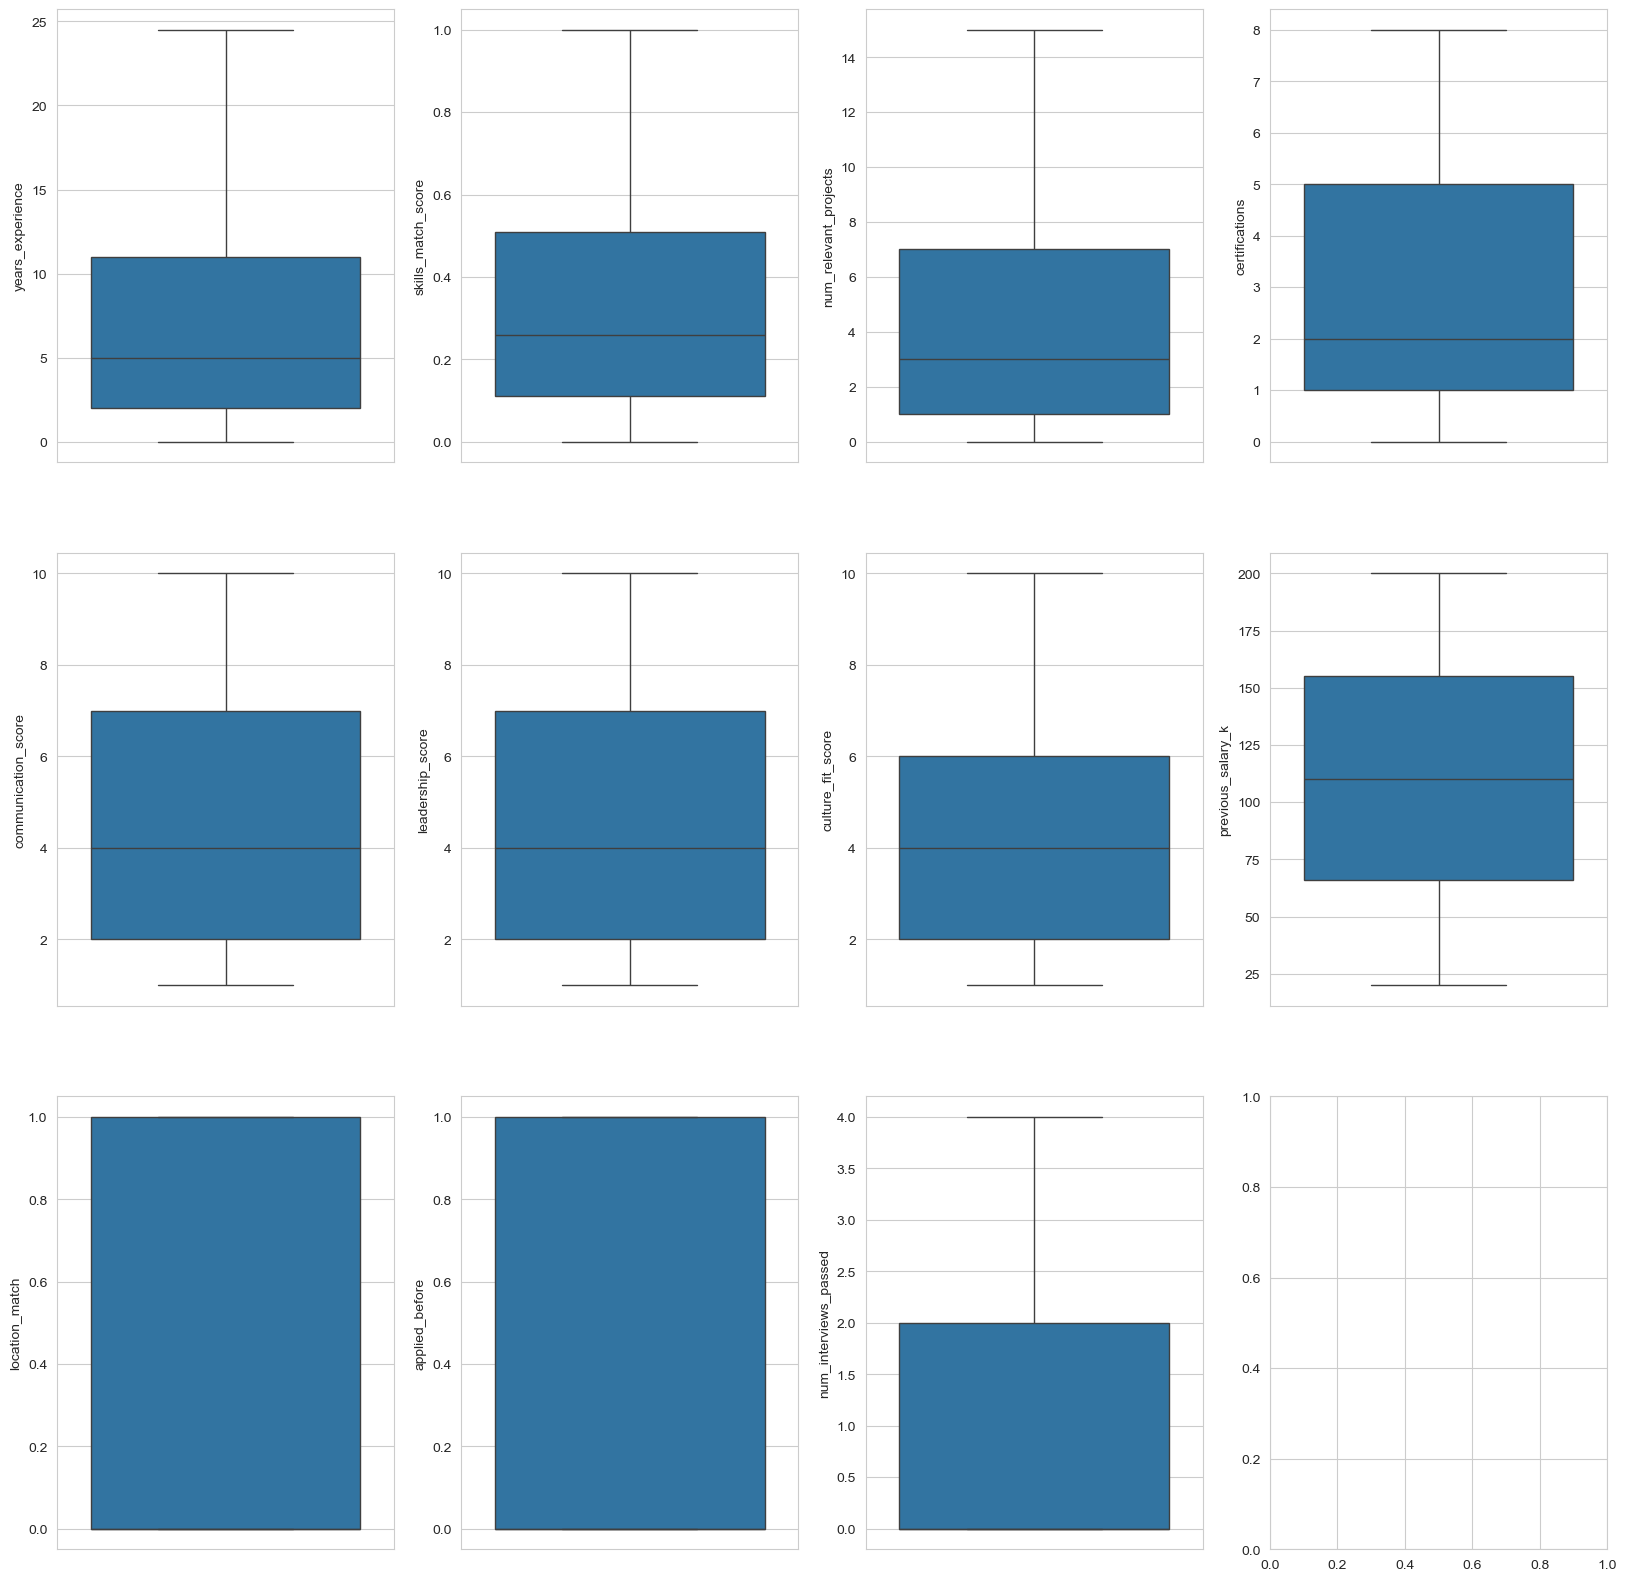

In [22]:
fig, ax = plt.subplots(nrows=3,ncols=4, figsize=(20,20))
ax = ax.flatten()
for nk, col in enumerate(numerical_columns):
    sns.boxplot(df[col], ax=ax[nk]) 
plt.show()
    

In [23]:
df["education_level"]

0          HS
1          HS
2          HS
3         PhD
4          HS
        ...  
995    Master
996    Master
997        HS
998    Master
999        HS
Name: education_level, Length: 1000, dtype: object

In [24]:
 df["label"].value_counts(normalize="true")*100

label
Best Suited for Role    33.4
Will Get Interview      33.3
Best Match for Role     33.3
Name: proportion, dtype: float64

<Axes: xlabel='label', ylabel='count'>

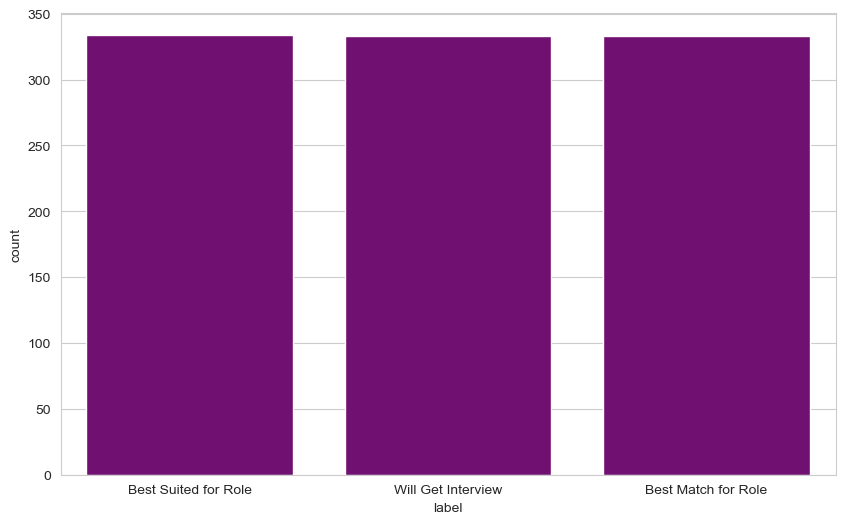

In [25]:
sns.countplot(
    x="label",
    data=df,
    order = df["label"].value_counts().index, color="purple")

In [26]:
yrs_experience = df.groupby("years_experience")["label"].value_counts()

print(yrs_experience)

years_experience  label               
0.0               Will Get Interview      68
                  Best Match for Role     50
                  Best Suited for Role    13
1.0               Will Get Interview      70
                  Best Match for Role     39
                                          ..
23.0              Best Suited for Role     8
24.0              Best Suited for Role    16
                  Best Match for Role      1
24.5              Best Suited for Role    46
                  Best Match for Role      2
Name: count, Length: 64, dtype: int64


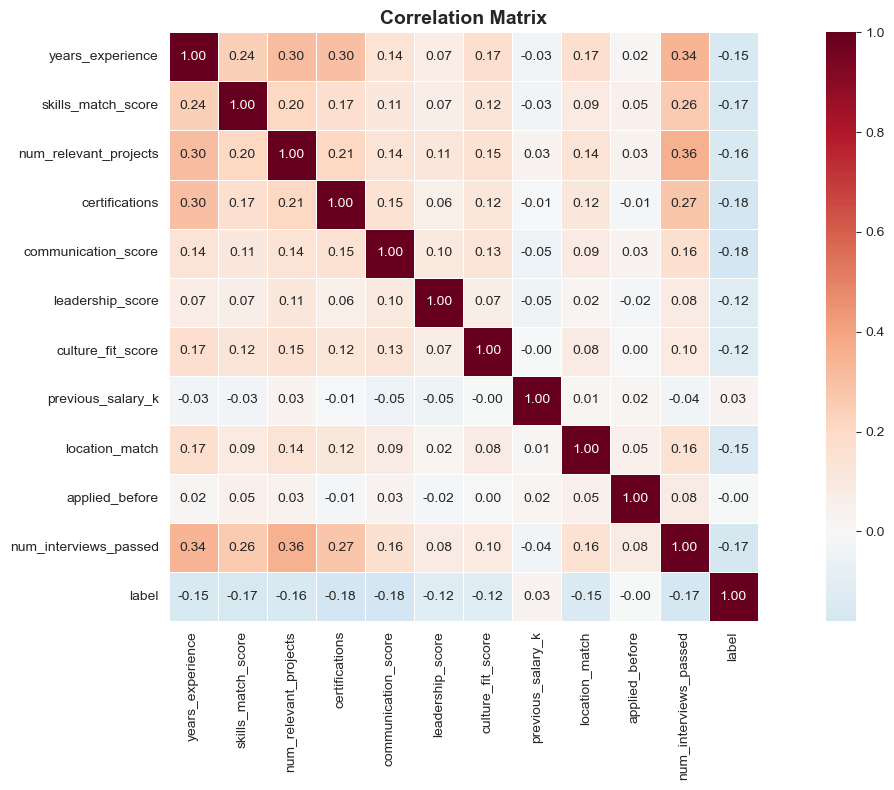

Correlations with label (sorted):
communication_score     -0.179948
certifications          -0.176064
num_interviews_passed   -0.172913
skills_match_score      -0.169174
num_relevant_projects   -0.160807
years_experience        -0.152789
location_match          -0.149318
culture_fit_score       -0.121068
leadership_score        -0.120895
previous_salary_k        0.028249
applied_before          -0.002461
Name: label, dtype: float64


In [27]:

# Values closer to +1 or -1 = stronger relationship

#### Mapping the column booking status with 0 and 1 to enbble pandas read it

df['label'] = df['label'].map({
    'Will Get Interview': 2,
    'Best Suited for Role': 1,
    'Best Match for Role': 0})

correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show which features correlate most with the target
print("Correlations with label (sorted):")
print(correlation_matrix['label'].drop('label').sort_values(key=abs, ascending=False))

In [28]:
cm_scores = df.groupby("communication_score")["label"].value_counts()
print(cm_scores)

communication_score  label
1                    2        88
                     0        60
                     1        30
2                    2        59
                     0        43
                     1        35
3                    2        59
                     0        37
                     1        35
4                    0        46
                     2        43
                     1        34
5                    0        37
                     2        37
                     1        34
6                    1        30
                     0        23
                     2        16
7                    0        27
                     1        26
                     2        13
8                    1        40
                     0        19
                     2         6
9                    1        45
                     0        21
                     2         9
10                   1        25
                     0        20
                

In [29]:
education_label = df.groupby("education_level")["label"].value_counts()

print(education_label)

education_level  label
Bachelor         0         88
                 1         81
                 2         32
HS               2        298
                 0        219
                 1         79
Master           1         84
                 0         18
                 2          2
PhD              1         90
                 0          8
                 2          1
Name: count, dtype: int64


In [30]:
df.head(10)

,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed,label
0,1.0,HS,0.37,3,2,5,5,1,47,0,0,0,2
1,1.0,HS,0.01,2,1,9,9,4,178,0,0,0,2
2,1.0,HS,0.21,4,1,1,4,1,124,1,1,0,2
3,16.0,PhD,0.97,6,2,5,1,8,115,0,0,2,1
4,22.0,HS,0.98,5,1,7,10,8,165,1,0,4,1
5,1.0,Bachelor,0.09,6,3,4,1,2,47,0,1,0,0
6,7.0,HS,0.93,5,1,3,1,3,153,0,0,0,0
7,1.0,Master,0.92,15,2,8,8,10,21,0,0,2,1
8,0.0,HS,0.20,8,3,2,4,1,52,0,0,0,2
9,3.0,HS,0.97,0,0,2,1,4,68,0,0,0,2


In [31]:
!pip install scikit_learn

In [32]:
encoder =LabelEncoder()

In [33]:
df["label"] = encoder.fit_transform(df["label"])
df["education_level"] = encoder.fit_transform(df["education_level"])

In [34]:
df.head(20)

,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed,label
0,1.0,1,0.37,3,2,5,5,1,47,0,0,0,2
1,1.0,1,0.01,2,1,9,9,4,178,0,0,0,2
2,1.0,1,0.21,4,1,1,4,1,124,1,1,0,2
3,16.0,3,0.97,6,2,5,1,8,115,0,0,2,1
4,22.0,1,0.98,5,1,7,10,8,165,1,0,4,1
5,1.0,0,0.09,6,3,4,1,2,47,0,1,0,0
6,7.0,1,0.93,5,1,3,1,3,153,0,0,0,0
7,1.0,2,0.92,15,2,8,8,10,21,0,0,2,1
8,0.0,1,0.20,8,3,2,4,1,52,0,0,0,2
9,3.0,1,0.97,0,0,2,1,4,68,0,0,0,2


In [35]:
df.head(10)

,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed,label
0,1.0,1,0.37,3,2,5,5,1,47,0,0,0,2
1,1.0,1,0.01,2,1,9,9,4,178,0,0,0,2
2,1.0,1,0.21,4,1,1,4,1,124,1,1,0,2
3,16.0,3,0.97,6,2,5,1,8,115,0,0,2,1
4,22.0,1,0.98,5,1,7,10,8,165,1,0,4,1
5,1.0,0,0.09,6,3,4,1,2,47,0,1,0,0
6,7.0,1,0.93,5,1,3,1,3,153,0,0,0,0
7,1.0,2,0.92,15,2,8,8,10,21,0,0,2,1
8,0.0,1,0.20,8,3,2,4,1,52,0,0,0,2
9,3.0,1,0.97,0,0,2,1,4,68,0,0,0,2


In [36]:
NUmber_cols_scale = ["years_experience","leadership_score","previous_salary_k","num_relevant_projects"]

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

In [39]:
df[NUmber_cols_scale] = scaler.fit_transform(df[NUmber_cols_scale]) 

In [40]:
df.head(20)

,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed,label
0,-0.845943,1,0.37,-0.360663,2,5,0.054127,1,-1.231969,0,0,0,2
1,-0.845943,1,0.01,-0.586926,1,9,1.424421,4,1.312298,0,0,0,2
2,-0.845943,1,0.21,-0.134400,1,1,-0.288447,1,0.263516,1,1,0,2
3,1.180430,3,0.97,0.318126,2,5,-1.316167,8,0.088719,0,0,2,1
4,1.990979,1,0.98,0.091863,1,7,1.766994,8,1.059814,1,0,4,1
5,-0.845943,0,0.09,0.318126,3,4,-1.316167,2,-1.231969,0,1,0,0
6,-0.035394,1,0.93,0.091863,1,3,-1.316167,3,0.826751,0,0,0,0
7,-0.845943,2,0.92,2.354494,2,8,1.081847,10,-1.736938,0,0,2,1
8,-0.981035,1,0.20,0.770652,3,2,-0.288447,1,-1.134860,0,0,0,2
9,-0.575760,1,0.97,-1.039453,0,2,-1.316167,4,-0.824110,0,0,0,2


In [41]:
!pip install imbalanced_learn

In [42]:
from imblearn.over_sampling import SMOTE

In [43]:
x = df.drop(columns=["label"], axis=1)
y = df["label"]

In [44]:
x.head()

,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed
0,-0.845943,1,0.37,-0.360663,2,5,0.054127,1,-1.231969,0,0,0
1,-0.845943,1,0.01,-0.586926,1,9,1.424421,4,1.312298,0,0,0
2,-0.845943,1,0.21,-0.134400,1,1,-0.288447,1,0.263516,1,1,0
3,1.180430,3,0.97,0.318126,2,5,-1.316167,8,0.088719,0,0,2
4,1.990979,1,0.98,0.091863,1,7,1.766994,8,1.059814,1,0,4


In [45]:
y.head()

0    2
1    2
2    2
3    1
4    1
Name: label, dtype: int64

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
y.value_counts(normalize="true")*100

label
1    33.4
2    33.3
0    33.3
Name: proportion, dtype: float64

<Axes: xlabel='label', ylabel='count'>

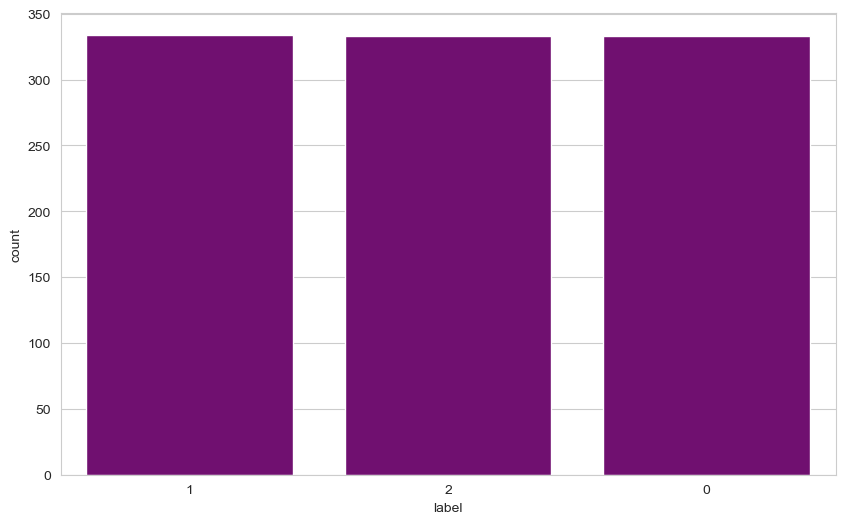

In [48]:
sns. countplot(
    x = "label",
    data = df,
order = df["label"].value_counts().index, color="purple")
    

In [49]:
smote = SMOTE(random_state=42)

In [50]:
smote = SMOTE(random_state=42)

In [51]:
x_resample, y_resample = smote.fit_resample(x, y)

In [52]:
y_resample.value_counts(normalize="true")*100

label
2    33.333333
1    33.333333
0    33.333333
Name: proportion, dtype: float64

In [53]:
x_resample.head()

,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed
0,-0.845943,1,0.37,-0.360663,2,5,0.054127,1,-1.231969,0,0,0
1,-0.845943,1,0.01,-0.586926,1,9,1.424421,4,1.312298,0,0,0
2,-0.845943,1,0.21,-0.134400,1,1,-0.288447,1,0.263516,1,1,0
3,1.180430,3,0.97,0.318126,2,5,-1.316167,8,0.088719,0,0,2
4,1.990979,1,0.98,0.091863,1,7,1.766994,8,1.059814,1,0,4


In [54]:
df = pd.DataFrame(x_resample, columns=x.columns)

In [55]:
df["label"] = y_resample

In [56]:
y_resample.value_counts()

label
2    334
1    334
0    334
Name: count, dtype: int64

In [57]:
x_resample.head()

,years_experience,education_level,skills_match_score,num_relevant_projects,certifications,communication_score,leadership_score,culture_fit_score,previous_salary_k,location_match,applied_before,num_interviews_passed
0,-0.845943,1,0.37,-0.360663,2,5,0.054127,1,-1.231969,0,0,0
1,-0.845943,1,0.01,-0.586926,1,9,1.424421,4,1.312298,0,0,0
2,-0.845943,1,0.21,-0.134400,1,1,-0.288447,1,0.263516,1,1,0
3,1.180430,3,0.97,0.318126,2,5,-1.316167,8,0.088719,0,0,2
4,1.990979,1,0.98,0.091863,1,7,1.766994,8,1.059814,1,0,4


In [58]:
from sklearn.model_selection import train_test_split

In [59]:
x_train, x_test, y_train, y_test = train_test_split(x_resample, y_resample, test_size=0.2,random_state=42)

In [60]:
print(f"training size {len(x_train)}")
print(f"testing size {len(x_test)}")

training size 801
testing size 201


In [61]:
y_resample.value_counts()

label
2    334
1    334
0    334
Name: count, dtype: int64

In [62]:
from sklearn.linear_model import LogisticRegression

In [63]:
model = LogisticRegression(random_state=42,class_weight="balanced")

In [64]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [65]:
y_pred = model.predict(x_test)

In [66]:
y_pred[:15]

array([2, 1, 2, 1, 2, 0, 1, 2, 2, 0, 2, 2, 2, 1, 1])

In [67]:
y.head()

0    2
1    2
2    2
3    1
4    1
Name: label, dtype: int64

In [68]:
print(y_pred[:15])

[2 1 2 1 2 0 1 2 2 0 2 2 2 1 1]


In [79]:
from sklearn.metrics import classification_report, confusion_matrix

In [80]:
from sklearn.metrics import confusion_matrix, classification_report

report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

print(report)
print(matrix)

              precision    recall  f1-score   support

           0       0.93      0.92      0.93        62
           1       1.00      0.95      0.97        73
           2       0.93      1.00      0.96        66

    accuracy                           0.96       201
   macro avg       0.95      0.95      0.95       201
weighted avg       0.96      0.96      0.96       201

[[57  0  5]
 [ 4 69  0]
 [ 0  0 66]]


In [81]:
from sklearn.linear_model import RandomForestClassifier

ImportError: cannot import name 'RandomForestClassifier' from 'sklearn.linear_model' (C:\Users\philip ibingha\.ipython\Lib\site-packages\sklearn\linear_model\__init__.py)

In [82]:
rf_model = RandomForestClassifier(random_state=42)

In [ ]:
rf_model.fit(x_train, y_train)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred[:15]

In [ ]:
2 1 2 1 2 0 1 2 2 0 2 2 2 1 1]

In [ ]:
y.head(12)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
report = classification_report(y_test, y_pred)
matrixm = confusion_matrix(y_test, y_pred)

print(report)
                    

In [73]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

In [74]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)}

                                                                                                                                    

In [83]:
models.items()

dict_items([('Random Forest', RandomForestClassifier(class_weight='balanced', random_state=42)), ('GradientBoosting', GradientBoostingClassifier(random_state=42)), ('AdaBoost', AdaBoostClassifier(random_state=42))])

In [84]:
results = {}

for model_name, model in models.items():

_IncompleteInputError: incomplete input (4035282042.py, line 3)

trainingRandom Forest....
Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        62
           1       0.94      0.89      0.92        73
           2       0.97      0.94      0.95        66

    accuracy                           0.91       201
   macro avg       0.91      0.91      0.91       201
weighted avg       0.91      0.91      0.91       201



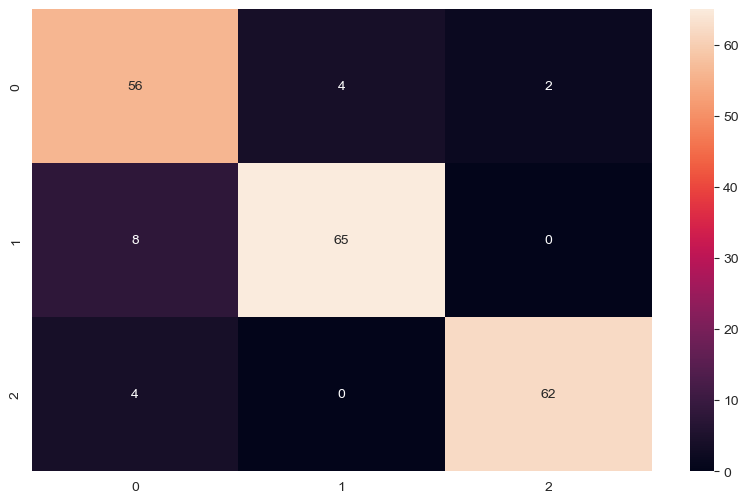

trainingGradientBoosting....
GradientBoosting Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        62
           1       0.95      0.86      0.91        73
           2       0.96      0.98      0.97        66

    accuracy                           0.92       201
   macro avg       0.92      0.92      0.91       201
weighted avg       0.92      0.92      0.92       201



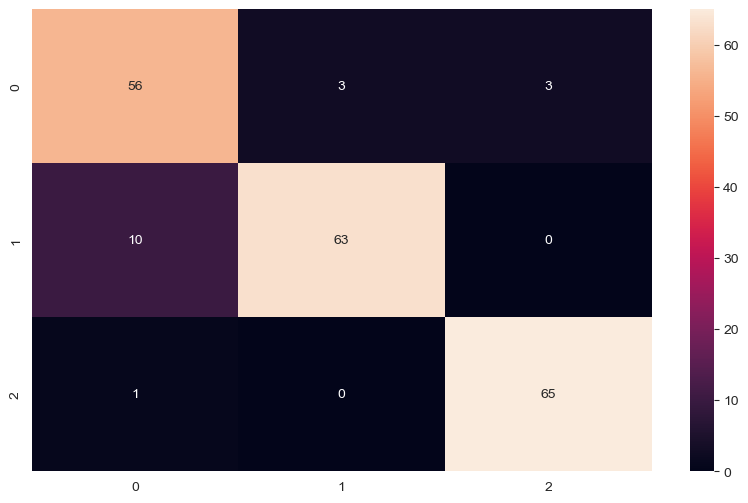

trainingAdaBoost....
AdaBoost Classification Report
              precision    recall  f1-score   support

           0       0.48      1.00      0.65        62
           1       1.00      0.90      0.95        73
           2       1.00      0.09      0.17        66

    accuracy                           0.67       201
   macro avg       0.83      0.67      0.59       201
weighted avg       0.84      0.67      0.60       201



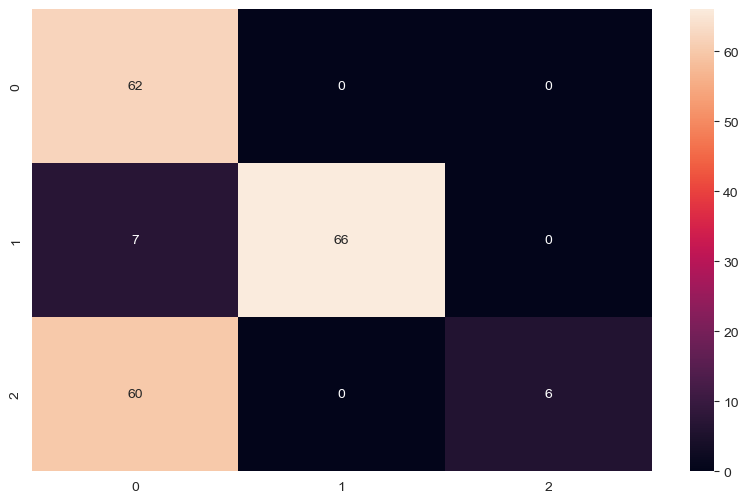

In [85]:
results = {}

for model_name, model in models.items():
    print(f"training{model_name}....")
    #training the model
    model.fit(x_train,y_train)
    # predicting model
    y_pred = model.predict(x_test)
    #evaluating the model
    accuracy = accuracy_score(y_test,y_pred)
    report = classification_report(y_test, y_pred)
    matrix = confusion_matrix(y_test, y_pred)

    #stores result
    results[model_name] = {
    "accuracy": accuracy,
    "classification_report": report,
    "confusion_matrix": matrix
}
    print(f"{model_name} Classification Report")
    print(report)
    sns.heatmap(matrix, annot=True, fmt="g")
    plt.show()

In [86]:
y.head(15)

0     2
1     2
2     2
3     1
4     1
5     0
6     0
7     1
8     2
9     2
10    2
11    2
12    2
13    0
14    2
Name: label, dtype: int64